<a href="https://colab.research.google.com/github/Cypheraj12/Heart_disease-prediction/blob/main/heart_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction Project

Includes:
- Data Loading
- EDA
- Missing Value Analysis
- Missing Value Handling
- Feature Engineering
- pd.get_dummies(drop_first=True)
- Logistic Regression
- Random Forest
- Accuracy, Classification Report
- Confusion Matrix


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

pd.set_option('display.max_columns', None)

df = pd.read_csv('heart_disease_uci.csv')

print("Shape:", df.shape)
display(df.head())


Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Column Meanings

| Column Name | Description                                                                                                                                                                             |
|-------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `id`          | Patient identifier.                                                                                                                                                                     |
| `age`         | Age of the patient in years.                                                                                                                                                            |
| `sex`         | Sex of the patient (Male/Female).                                                                                                                                                       |
| `dataset`     | Origin of the data (e.g., Cleveland, Hungary, Switzerland, VA Long Beach).                                                                                                              |
| `cp`          | Chest pain type: atypical angina, non-anginal, typical angina, asymptomatic.                                                                                                            |
| `trestbps`    | Resting blood pressure (mm Hg).                                                                                                                                                         |
| `chol`        | Serum cholesterol (mg/dl).                                                                                                                                                              |
| `fbs`         | Fasting blood sugar > 120 mg/dl (True/False, indicating if fasting blood sugar is high).                                                                                                |
| `restecg`     | Resting electrocardiographic results: normal, st-t abnormality (ST-T wave abnormality), lv hypertrophy (definite left ventricular hypertrophy).                                         |
| `thalch`      | Maximum heart rate achieved.                                                                                                                                                            |
| `exang`       | Exercise induced angina (True/False).                                                                                                                                                   |
| `oldpeak`     | ST depression induced by exercise relative to rest.                                                                                                                                     |
| `slope`       | The slope of the peak exercise ST segment: upsloping, flat, downsloping.                                                                                                                |
| `ca`          | Number of major vessels (0-3) colored by fluoroscopy.                                                                                                                                   |
| `thal`        | Thalassemia type: normal, fixed defect, reversable defect.                                                                                                                              |
| `num`         | Diagnosis of heart disease (angiographic disease status, integer value 0-4; 0 = no disease, > 0 = disease). This is often used to derive the binary target variable for heart disease. |                                                                                                   |


In [ ]:

# Basic EDA

print(df.info())
print("\nMissing Values\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

display(df.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Missing Values

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol       

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


In [ ]:

# Convert target to binary

df['num'] = (df['num'] > 0).astype(int)

print(df['num'].value_counts())


num
1    509
0    411
Name: count, dtype: int64


In [ ]:
#importance of each feature
df.corr(numeric_only=True)["num"]

,num
id,0.356086
age,0.282700
trestbps,0.106233
chol,-0.230583
thalch,-0.394503
oldpeak,0.385528
ca,0.455599
num,1.000000


In [ ]:

# Missing Value Handling

numeric_cols = ['trestbps','chol','thalch','oldpeak']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in ['fbs','restecg','exang']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['slope'] = df['slope'].fillna('Missing')
df['thal'] = df['thal'].fillna('Missing')

# ca has many missing values
df['ca'] = df['ca'].fillna(-1)

print(df.isnull().sum())


id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


/tmp/ipykernel_2070/4144872050.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:

# Feature Engineering

df['ca_missing'] = (df['ca'] == -1).astype(int)
df['thal_missing'] = (df['thal'] == 'Missing').astype(int)

df['age_oldpeak'] = df['age'] * df['oldpeak']


In [ ]:

# Prepare Features

X = df.drop(columns=['num'])

if 'id' in X.columns:
    X = X.drop(columns=['id'])

y = df['num']

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print("Encoded Shape:", X.shape)
display(X.head())


Encoded Shape: (920, 26)


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,ca_missing,thal_missing,age_oldpeak,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,0,144.9,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0
1,67,160.0,286.0,False,108.0,True,1.5,3.0,0,0,100.5,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,67,120.0,229.0,False,129.0,True,2.6,2.0,0,0,174.2,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,0,129.5,1,0,0,0,0,1,0,1,0,1,0,0,0,1,0
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,0,57.4,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0


In [ ]:

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=59,
    stratify=y
)

print(X_train.shape, X_test.shape)


(736, 26) (184, 26)


Logistic Regression Accuracy: 0.8913043478260869
              precision    recall  f1-score   support

           0       0.87      0.89      0.88        82
           1       0.91      0.89      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



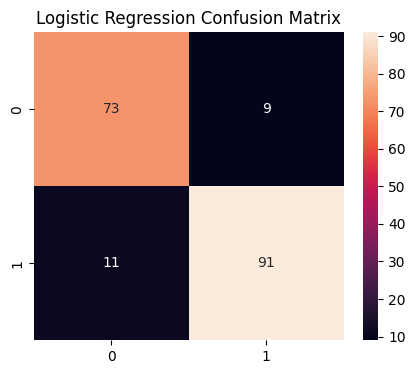

In [ ]:

# Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


Random Forest Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        82
           1       0.89      0.87      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



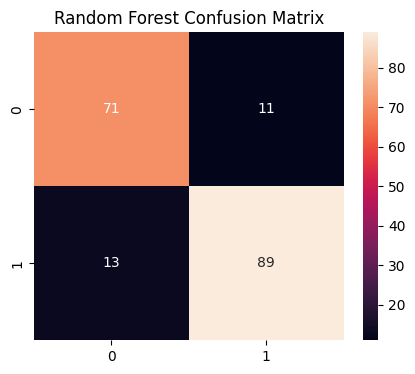

In [ ]:

# Random Forest

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.show()
